# 05 — Muograma del Fuego con DEM real

Mismo pipeline que el notebook 04, pero reemplazando el cono sintético por la **topografía real** del Volcán de Fuego.

## ¿Qué es un DEM?

DEM = **Digital Elevation Model**. Es una **tabla de elevaciones**: una grilla regular sobre la superficie de la Tierra donde cada celda dice "en este punto el terreno está a tantos metros sobre el nivel del mar". Conceptualmente es como una imagen, sólo que en vez de pixeles con (R, G, B) tiene pixeles con altitud:

```
... 3201  3245  3290  3340 ...        Cada celda = 30 m × 30 m (en este DEM)
... 3198  3240  3300  3380 ...        Valor = altitud z (m)
... 3185  3220  3280  3370 ...
```

Se almacena típicamente en **GeoTIFF**: un archivo TIFF estándar al que se le agregan metadatos de georeferenciación — en qué latitud/longitud arranca el pixel (0,0), qué tamaño tiene cada pixel, qué datum vertical usa, qué sistema de coordenadas (CRS) tiene asignado.

## ¿De dónde sale este DEM?

Usamos **Copernicus DEM GLO-30** (a veces llamado COP-DEM o CopDEM30):

- Producido por la Agencia Espacial Europea (ESA) a partir de la misión **TanDEM-X** (radar interferométrico de la DLR alemana).
- Resolución: ~30 m por pixel.
- Cobertura global, datos públicos y gratuitos.
- Hospedaje: AWS Open Data, **sin autenticación**. Se baja con un `curl` directo.
- Cada archivo cubre 1° × 1° de latitud/longitud (~3600 × 3600 pixeles). Fuego (14.47° N, 90.88° W) cae dentro del tile que cubre N14–N15, W091–W090.

URL exacta usada:

```
https://copernicus-dem-30m.s3.amazonaws.com/Copernicus_DSM_COG_10_N14_00_W091_00_DEM/Copernicus_DSM_COG_10_N14_00_W091_00_DEM.tif
```

Tamaño: 44 MB. En el repo está en `data/dem/` (excluido de git por tamaño; se baja con `make download-dem`).

### Por qué Copernicus y no otra fuente

| Fuente | Resolución | Notas |
|---|---|---|
| **SRTM v3 (NASA)** | 30 m | Misión año 2000; tiene huecos en zonas montañosas, requiere login Earthdata. |
| **ASTER GDEM** | 30 m | Ruidoso comparado con SRTM y Copernicus. |
| **AW3D30 (JAXA)** | 30 m gratis / 12.5 m de pago | Estéreo óptico; muy buen detalle, gratuito hasta 30 m. |
| **Copernicus GLO-30** | 30 m | Más nuevo (2010–2015), limpio, **sin auth**. Lo elegimos por reproducibilidad. |

Para Guatemala, Copernicus tiene calidad similar a SRTM con la ventaja de descarga sin login. Si el comité de tesis pide otro DEM como referencia cruzada, los demás se pueden bajar siguiendo el mismo patrón y el código del notebook funciona igual.

## ¿Cómo lo usamos?

El módulo `analysis.muograma.DEMTerrain` hace cuatro cosas al cargar el archivo:

1. **Leerlo entero a memoria** con `rasterio` (44 MB, cabe sin problema).
2. **Definir un sistema local plano**: origen en la cima del Fuego, ejes (este, norte, arriba) en metros. La proyección es **UTM zona 15N** (EPSG 32615), que es la zona geodésica estándar para Guatemala. Deformación < 0.1 % en una ventana de ±20 km — irrelevante para nuestra escala.
3. **Interpolación bilineal**: dado un punto $(x, y)$ en metros locales, el código lo convierte a (lon, lat), encuentra los 4 pixeles vecinos en el raster, y promedia sus elevaciones según las distancias. Eso evita escalones cuando un rayo cruza fronteras de pixel.
4. **Función `is_inside(x, y, z)`**: regresa `True` donde $z < \text{DEM}(x, y)$, es decir, el punto está bajo la superficie del terreno → está dentro de roca.

**Toda la sustitución se reduce a esa última línea.** El resto del pipeline (CSDA, integral de Reyna, transmisión) no se entera de si la geometría viene de un cono o de un DEM.

### Gotchas técnicos relevantes

1. **Proyección**: si trabajáramos con grados de lat/long directamente, las distancias horizontales no estarían en metros y el ray tracing produciría basura. Por eso el DEM se proyecta a UTM antes de hacer cualquier cálculo geométrico.
2. **Datum vertical**: Copernicus usa el geoide EGM2008. SRTM usa EGM96. La diferencia en Guatemala es ~25 m. Para muografía (que mira centenares de metros de roca) es despreciable, pero hay que documentarlo en la metodología.
3. **El DEM ve la copa de los árboles** ("Digital Surface Model"), no el suelo. En selva tropical pueden ser ~30 m extra. Fuego está por encima de la línea de árboles en su parte alta, así que el sesgo es chico, pero existe.
4. **Resolución vertical**: ~10 m de incertidumbre. Despreciable a esta escala.

## Qué cambia respecto al cono sintético del notebook 04

El cono era simétrico, suave y centrado. El terreno real:
- **Es asimétrico**: Fuego está pegado a Acatenango al norte — la línea de visión también puede atravesar la masa del vecino.
- **Tiene flancos con pendientes diferentes** (más empinado al NE, más suave al SW).
- **Tiene topografía circundante**: barrancos, valles. Un rayo casi horizontal puede atravesar muchos km de tierra hasta salir al cielo.

## Lo que NO cambia

Todo lo demás: la pérdida de energía CSDA, la integral de Reyna, la definición de transmisión. Sólo el primer paso (¿qué punto está dentro de la roca?) se sustituye.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PAPER_FIGS = REPO_ROOT.parent / 'muon-tomography-paper' / 'figures'

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, LightSource

from analysis.muograma import (
    DEMTerrain, ConicalVolcano, rock_opacity_grid, csda_min_momentum, transmission_map,
)

## 0. Volcán objetivo

Cambiá `TARGET_VOLCAN` para apuntar a otro de los 4 volcanes (`fuego`, `acatenango`, `pacaya`, `agua`). Todos los params geométricos (lat/lon del cráter, geometría del cono, estación por defecto) vienen de `data/volcanoes.yaml`.

In [2]:
# Target volcano. Read params from data/volcanoes.yaml so the same notebook
# works for fuego / acatenango / pacaya / agua. Edit the string below to
# switch volcanoes; the default station and cone params come from the YAML.
TARGET_VOLCAN = "fuego"

# Override the station explicitly if you want a different one than the
# default (data/volcanoes.yaml -> default_station). Set to None to use default.
STATION_NAME_OVERRIDE = None

import yaml
with open(REPO_ROOT / "data" / "volcanoes.yaml") as _f:
    VOLCAN_CFG = yaml.safe_load(_f)[TARGET_VOLCAN]
STATION_NAME = STATION_NAME_OVERRIDE or VOLCAN_CFG["default_station"]
# Per-volcano filename suffix for paper figures (empty for fuego = backward compat).
VOL_SUFFIX = "" if TARGET_VOLCAN == "fuego" else f"_{TARGET_VOLCAN}"

print(f"TARGET_VOLCAN = {TARGET_VOLCAN}")
print(f"  Catalogued summit: ({VOLCAN_CFG['lat']}, {VOLCAN_CFG['lon']}) at {VOLCAN_CFG['summit_m']} m")
print(f"  Cone: base {VOLCAN_CFG['cone']['base_m']} m, radius {VOLCAN_CFG['cone']['base_radius_m']} m,"
      f" density {VOLCAN_CFG['cone']['density_gcc']} g/cc")
print(f"  Default station: {STATION_NAME}")

TARGET_VOLCAN = fuego
  Catalogued summit: (14.473, -90.88) at 3763 m
  Cone: base 2500 m, radius 1500 m, density 2.65 g/cc
  Default station: FG16


## 1. Cargar el DEM y ver la topografía

Origen del sistema local = cima del Fuego (14.4747° N, 90.8806° W). Coordenadas en metros relativas a la cima, ejes (este, norte, arriba). Proyección plana = UTM zona 15N (deformación < 0.1% en una ventana de ±20 km, suficiente para muografía).

In [3]:
DEM_FILE = REPO_ROOT / 'data' / 'dem' / 'Copernicus_DSM_COG_10_N14_00_W091_00_DEM.tif'
if not DEM_FILE.exists():
    raise FileNotFoundError(
        f'Falta {DEM_FILE}. Bajarlo con:\n'
        '  curl -fsSL -o data/dem/Copernicus_DSM_COG_10_N14_00_W091_00_DEM.tif \\\n'
        '    https://copernicus-dem-30m.s3.amazonaws.com/Copernicus_DSM_COG_10_N14_00_W091_00_DEM/Copernicus_DSM_COG_10_N14_00_W091_00_DEM.tif'
    )

terrain = DEMTerrain(DEM_FILE,
                     origin_lonlat=(VOLCAN_CFG['lon'], VOLCAN_CFG['lat']),
                     density_gcc=VOLCAN_CFG['cone']['density_gcc'])

print(f'CRS del DEM:       {terrain.dem_crs}')
print(f'Proyección local:  UTM zona 15N (EPSG:{terrain.utm_epsg})')
print(f'Origen UTM (E,N):  ({terrain.origin_utm[0]:.0f}, {terrain.origin_utm[1]:.0f}) m')
print(f'Elevación en el origen (cima de {TARGET_VOLCAN} según DEM): {terrain.summit_elevation:.0f} m')
print(f'  (vs. valor catalogado {VOLCAN_CFG["summit_m"]} m — la diferencia es por depósitos eruptivos y resolución del DEM)')

CRS del DEM:       EPSG:4326
Proyección local:  UTM zona 15N (EPSG:32615)
Origen UTM (E,N):  (728510, 1601096) m
Elevación en el origen (cima de fuego según DEM): 3672 m
  (vs. valor catalogado 3763 m — la diferencia es por depósitos eruptivos y resolución del DEM)


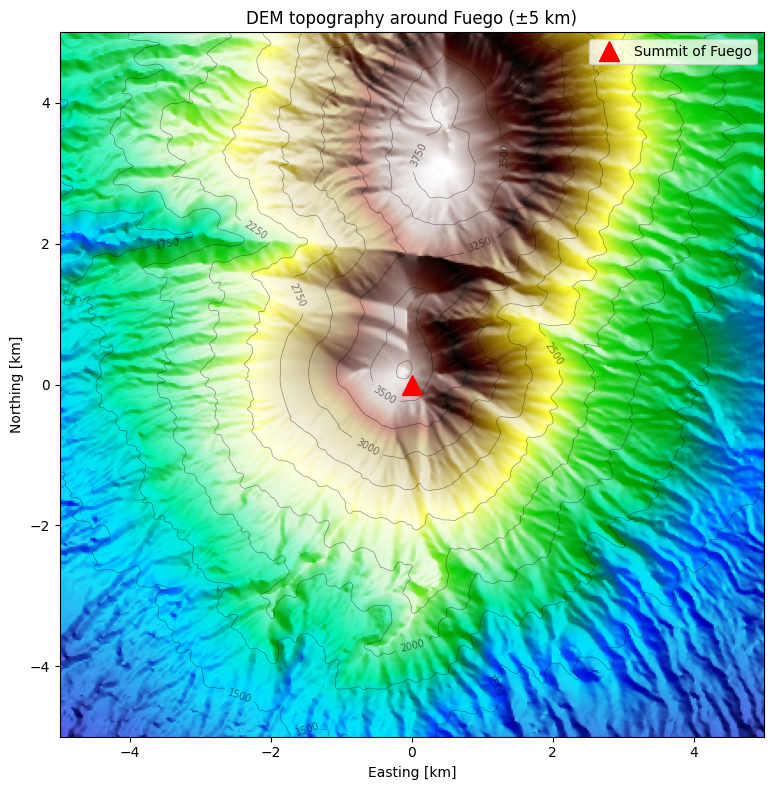

Rango de elevación en la ventana: 1099 – 3967 m
Nota: la masa al N de la cima (~+5 km) es Acatenango (3,976 m).


In [4]:
# Ventana ±5 km alrededor de la cima
extent_m = 5000
xs = np.linspace(-extent_m, extent_m, 400)
ys = np.linspace(-extent_m, extent_m, 400)
X, Y = np.meshgrid(xs, ys)
Z = terrain.elevation_at(X, Y)

# Hillshade para realzar la topografía
ls = LightSource(azdeg=315, altdeg=45)
rgb = ls.shade(Z, cmap=plt.cm.terrain, vert_exag=2.0, blend_mode='overlay')

fig, ax = plt.subplots(figsize=(9, 8))
ax.imshow(rgb, extent=[-extent_m/1000, extent_m/1000, -extent_m/1000, extent_m/1000],
          origin='lower')
cs = ax.contour(X/1000, Y/1000, Z, levels=np.arange(1500, 4000, 250),
                colors='k', linewidths=0.4, alpha=0.5)
ax.clabel(cs, inline=True, fontsize=7, fmt='%d')
ax.plot(0, 0, 'r^', markersize=14, label=f'Summit of {TARGET_VOLCAN.title()}')
ax.set_xlabel('Easting [km]')
ax.set_ylabel('Northing [km]')
ax.set_title(f'DEM topography around {TARGET_VOLCAN.title()} (±5 km)')
ax.legend(loc='upper right')
ax.set_aspect('equal')
plt.tight_layout()
fig.savefig(PAPER_FIGS / f'fig_dem_topography{VOL_SUFFIX}.png', bbox_inches='tight', dpi=300)
plt.show()

print(f'Rango de elevación en la ventana: {Z.min():.0f} – {Z.max():.0f} m')
if TARGET_VOLCAN == 'fuego':
    print('Nota: la masa al N de la cima (~+5 km) es Acatenango (3,976 m).')
elif TARGET_VOLCAN == 'acatenango':
    print('Nota: la masa al S de la cima (~-5 km) es Fuego (3,763 m).')

## 2. Posición del detector

Coloco el detector **3 km al este de la cima**, sobre el terreno (a 2 m de altura), donde la elevación es ~2.1 km. Esa es una zona accesible (carretera y planicies al este de Fuego). El detector mira hacia el oeste (hacia la cima).

In [5]:
# Detector position from the curated INSIVUMEH station roster.
# STATION_NAME and TARGET_VOLCAN come from cell 2 (TARGET_VOLCAN config).
import pandas as pd
from pyproj import Transformer

_sites = pd.read_csv(REPO_ROOT / "data" / "detector_sites.csv")
_mask = (_sites["name"] == STATION_NAME) & (_sites["target_volcan"] == TARGET_VOLCAN)
if not _mask.any():
    raise ValueError(f"({STATION_NAME!r}, {TARGET_VOLCAN!r}) not in data/detector_sites.csv")
_site = _sites[_mask].iloc[0]

# Convert station (lat, lon) to detector (det_x, det_y) relative to the
# DEM origin (= crater of the target volcano).
_tx = Transformer.from_crs("EPSG:4326", f"EPSG:{terrain.utm_epsg}", always_xy=True)
_e_utm, _n_utm = _tx.transform(_site["lon"], _site["lat"])
det_x = float(_e_utm - terrain.origin_utm[0])
det_y = float(_n_utm - terrain.origin_utm[1])
det_z_ground = float(terrain.elevation_at(np.array(det_x), np.array(det_y)))
det_z = det_z_ground + 2.0
detector_xyz = (det_x, det_y, det_z)

# Vista de la cima desde el detector
summit_z = terrain.summit_elevation
dx, dy, dz = -det_x, -det_y, summit_z - det_z
dist_horiz = np.hypot(dx, dy)
elev_summit_deg = np.degrees(np.arctan2(dz, dist_horiz))
theta_summit_deg = 90.0 - elev_summit_deg
phi_summit_deg = np.degrees(np.arctan2(dy, dx)) % 360.0

print(f"Station: {_site['name']!r} ({_site['fuente']}) targeting {TARGET_VOLCAN}")
print(f"  Coords (lat, lon): ({_site['lat']:.4f}, {_site['lon']:.4f})")
print(f"  Distance to crater (per roster): {_site['dist_km']:.2f} km")
print(f"Detector en (este, norte, z) = ({det_x:.0f}, {det_y:.0f}, {det_z:.0f}) m")
print(f"  Terreno bajo el detector: {det_z_ground:.0f} m  (detector 2 m arriba)")
print(f"  Distancia horizontal al eje del volcán: {dist_horiz:.0f} m")
print(f"Cima vista desde el detector:")
print(f"  θ = {theta_summit_deg:.1f}°  (elevación = {elev_summit_deg:.1f}°)")
print(f"  φ = {phi_summit_deg:.0f}°  (math convention: 0°=E, 90°=N, 180°=W, 270°=S)")


Station: 'FG16' (INSIVUMEH-RSN) targeting fuego
  Coords (lat, lon): (14.4550, -90.8508)
  Distance to crater (per roster): 3.72 km
Detector en (este, norte, z) = (3165, -1959, 1741) m
  Terreno bajo el detector: 1739 m  (detector 2 m arriba)
  Distancia horizontal al eje del volcán: 3722 m
Cima vista desde el detector:
  θ = 62.6°  (elevación = 27.4°)
  φ = 148°  (math convention: 0°=E, 90°=N, 180°=W, 270°=S)


## 3. Ray tracing sobre la malla angular

Misma malla que en el notebook 04 (θ ∈ [40°, 85°], φ ∈ [120°, 240°], paso 0.5°). Como el terreno es más complejo, uso `max_length_m = 8 km` (suficiente para atravesar la mole de Fuego, sin meternos en el flanco de Acatenango para que la imagen quede dominada por el volcán objetivo).

In [6]:
theta_deg = np.arange(40.0, 85.5, 0.5)
# Re-center the azimuth grid on the crater direction (phi_summit_deg, computed
# above from the detector coords). ±60° gives a 120° wedge covering the
# volcanic edifice plus generous open-sky margin on both sides.
_phi_half = 60.0
phi_deg = np.arange(phi_summit_deg - _phi_half, phi_summit_deg + _phi_half + 0.5, 0.5)
theta_rad = np.radians(theta_deg)
phi_rad   = np.radians(phi_deg)

L_dem = rock_opacity_grid(
    terrain, detector_xyz, theta_rad, phi_rad,
    max_length_m=8_000.0, n_steps=400,
)

# Por comparación: misma malla con el cono sintético del notebook 04
target_cone = ConicalVolcano(
    (0, 0, terrain.summit_elevation),
    VOLCAN_CFG['cone']['base_m'],
    VOLCAN_CFG['cone']['base_radius_m'],
    VOLCAN_CFG['cone']['density_gcc'],
)
L_cone = rock_opacity_grid(target_cone, detector_xyz, theta_rad, phi_rad,
                           max_length_m=8_000.0, n_steps=400)

print('Comparación DEM vs cono sintético:')
print(f'  Pixeles con roca (DEM):  {(L_dem > 0).sum()} / {L_dem.size}  ({(L_dem > 0).mean():.1%})')
print(f'  Pixeles con roca (cono): {(L_cone > 0).sum()} / {L_cone.size}  ({(L_cone > 0).mean():.1%})')
print(f'  L max (DEM):  {L_dem.max():.0f} g/cm² ≈ {L_dem.max() / terrain.density_gcc / 100:.0f} m')
print(f'  L max (cono): {L_cone.max():.0f} g/cm² ≈ {L_cone.max() / 2.65 / 100:.0f} m')

Comparación DEM vs cono sintético:
  Pixeles con roca (DEM):  7337 / 21931  (33.5%)
  Pixeles con roca (cono): 2246 / 21931  (10.2%)
  L max (DEM):  2093500 g/cm² ≈ 7900 m
  L max (cono): 577700 g/cm² ≈ 2180 m


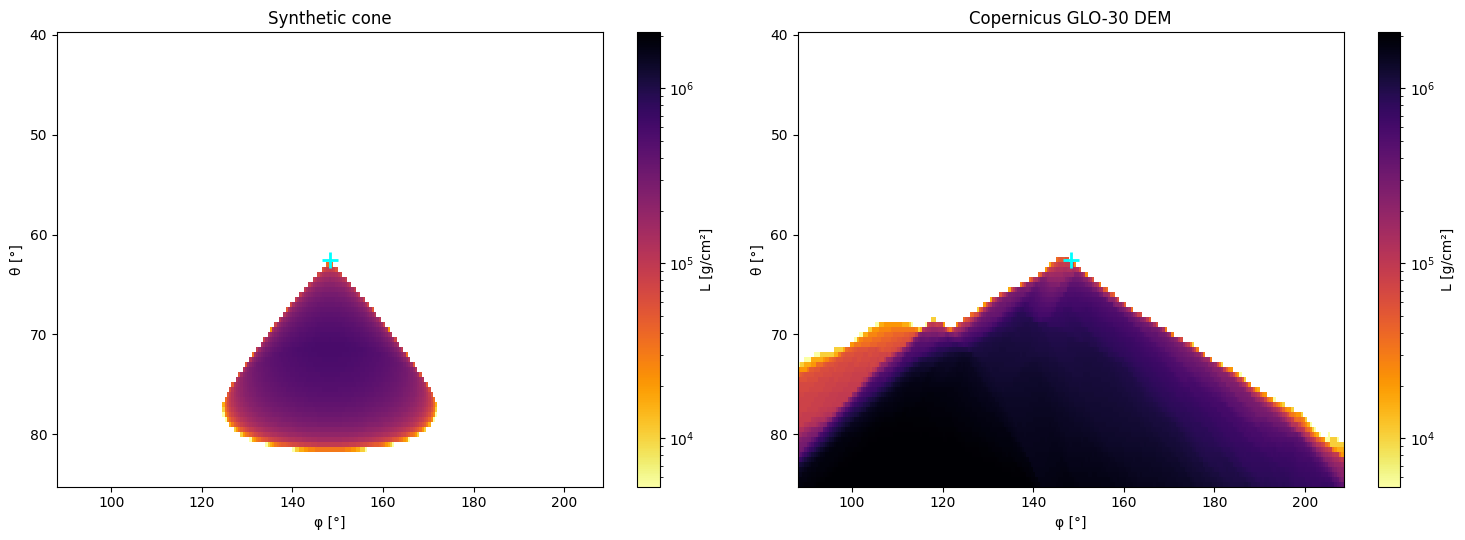

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
PHI, THETA = np.meshgrid(phi_deg, theta_deg)

# Mismo rango de color para los dos plots
vmin = max(1e2, min(L_dem[L_dem>0].min(), L_cone[L_cone>0].min()))
vmax = max(L_dem.max(), L_cone.max())

for ax, L, title in [(axes[0], L_cone, 'Synthetic cone'),
                      (axes[1], L_dem,  'Copernicus GLO-30 DEM')]:
    Lp = np.where(L > 0, L, np.nan)
    im = ax.pcolormesh(PHI, THETA, Lp, cmap='inferno_r', shading='auto',
                       norm=LogNorm(vmin=vmin, vmax=vmax))
    ax.scatter(phi_summit_deg, theta_summit_deg, marker='+', s=140, color='cyan', lw=2)
    ax.set_xlabel('φ [°]', fontsize=20)
    ax.set_ylabel('θ [°]', fontsize=20)
    ax.tick_params(labelsize=18)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=18)
    cb = plt.colorbar(im, ax=ax)
    cb.set_label('L [g/cm²]', fontsize=16)
    cb.ax.tick_params(labelsize=15)

plt.tight_layout()
fig.savefig(PAPER_FIGS / f'fig_muograma_sintetico_dem{VOL_SUFFIX}.png', bbox_inches='tight', dpi=300)
plt.show()

## 4. Muograma — transmisión $T(θ, φ)$

Mismo cálculo que el notebook 04 (CSDA + Reyna). Acá la diferencia interesante es ver **dónde aparecen detalles asimétricos** que el cono sintético no podía mostrar.

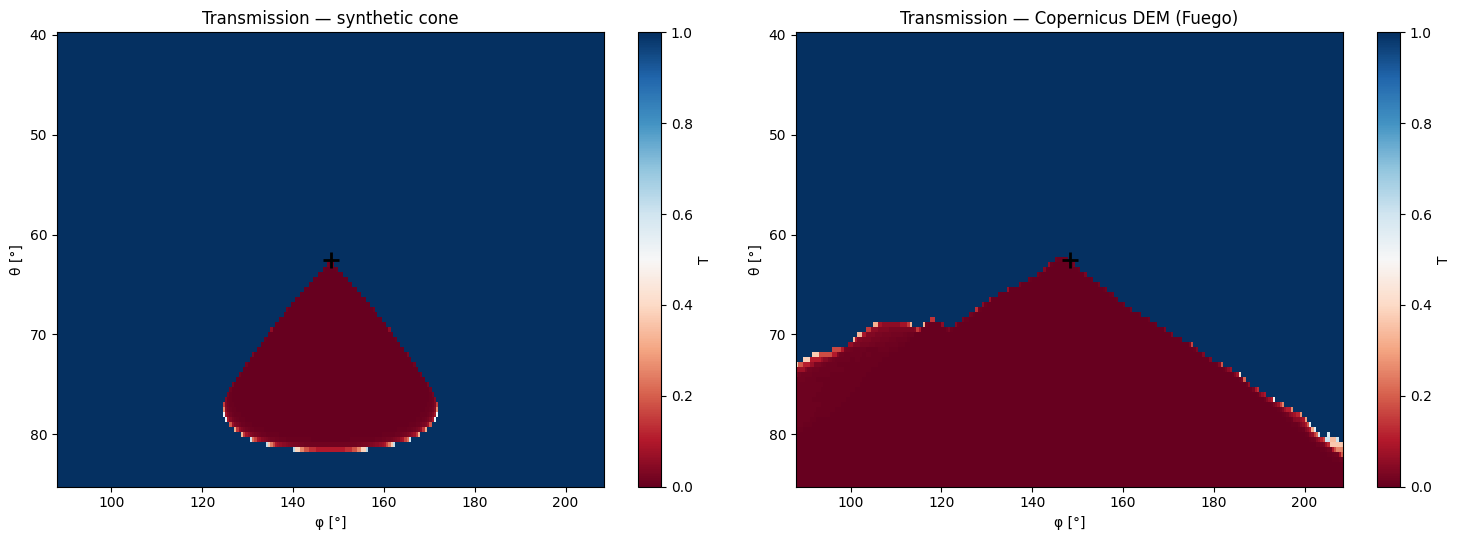

T mínima (DEM):  0.00e+00
Pixeles con T < 0.5 (DEM): 7330 (33.4%)
Pixeles con T > 0.99 (DEM, cielo abierto): 14594 (66.5%)


In [8]:
T_dem  = transmission_map(L_dem,  theta_rad)
T_cone = transmission_map(L_cone, theta_rad)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, T, title in [(axes[0], T_cone, 'Transmission — synthetic cone'),
                      (axes[1], T_dem,  f'Transmission — Copernicus DEM ({TARGET_VOLCAN.title()})')]:
    im = ax.pcolormesh(PHI, THETA, T, cmap='RdBu', shading='auto', vmin=0, vmax=1)
    ax.scatter(phi_summit_deg, theta_summit_deg, marker='+', s=140, color='black', lw=2)
    ax.set_xlabel('φ [°]', fontsize=20)
    ax.set_ylabel('θ [°]', fontsize=20)
    ax.tick_params(labelsize=18)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=18)
    cb = plt.colorbar(im, ax=ax)
    cb.set_label('T', fontsize=16)
    cb.ax.tick_params(labelsize=15)
plt.tight_layout()
fig.savefig(PAPER_FIGS / f'fig_T_cone_vs_dem{VOL_SUFFIX}.png', bbox_inches='tight', dpi=300)
plt.show()

print(f'T mínima (DEM):  {T_dem.min():.2e}')
print(f'Pixeles con T < 0.5 (DEM): {(T_dem < 0.5).sum()} ({(T_dem < 0.5).mean():.1%})')
print(f'Pixeles con T > 0.99 (DEM, cielo abierto): {(T_dem > 0.99).sum()} ({(T_dem > 0.99).mean():.1%})')

## 5. Donde el DEM se diferencia del cono — el "residuo"

Lo verdaderamente útil no es el muograma per se, sino el **residuo** entre el DEM real y un modelo geométrico simple. En muografía real esa es la señal del *trabajo de investigación*: zonas donde el flujo medido se desvía del esperado podrían ser **cámaras magmáticas, conductos, cavidades** o cualquier inhomogeneidad de densidad.

Acá comparamos DEM vs cono perfecto. Las diferencias revelan asimetrías de la **topografía** (no de densidad — la densidad está fija a 2.65). Cuando midamos muones reales y los comparemos con esta predicción DEM, las diferencias indicarán cambios de **densidad**.

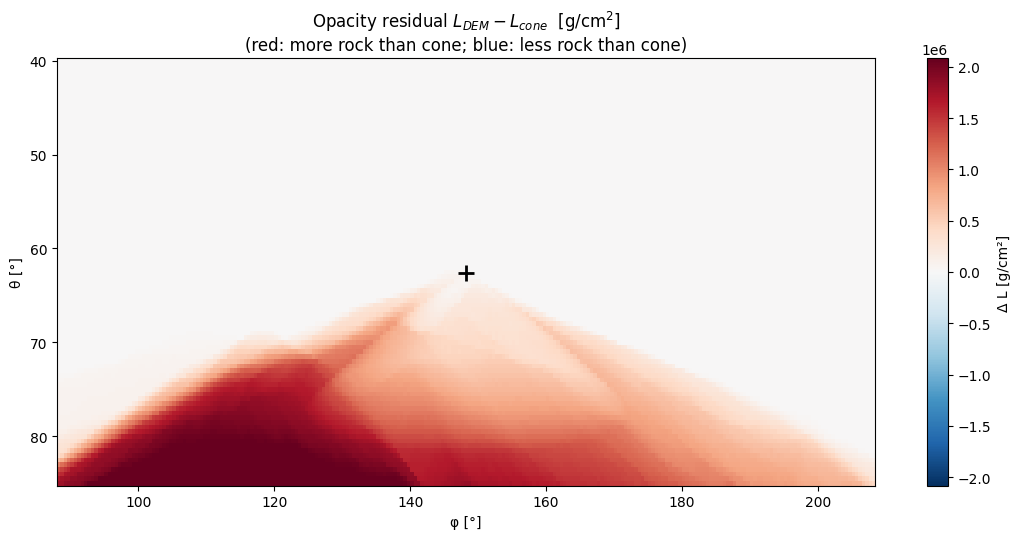

Pixeles con roca en AMBOS modelos:  2246
Solo en DEM (cono lo perdió):       5091
Solo en cono (DEM lo perdió):       0
Residuo medio (donde ambos tienen roca): +814164 g/cm²


In [9]:
# Diferencia de opacidad en regiones donde ambos modelos tienen roca, o donde uno la tiene y el otro no.
delta_L = L_dem - L_cone
vmax = np.percentile(np.abs(delta_L), 99)

fig, ax = plt.subplots(figsize=(11, 5.5))
im = ax.pcolormesh(PHI, THETA, delta_L, cmap='RdBu_r', shading='auto', vmin=-vmax, vmax=vmax)
ax.scatter(phi_summit_deg, theta_summit_deg, marker='+', s=140, color='black', lw=2)
ax.set_xlabel('φ [°]'); ax.set_ylabel('θ [°]')
ax.invert_yaxis()
ax.set_title('Opacity residual $L_{DEM} - L_{cone}$  [g/cm$^2$]\n'
             '(red: more rock than cone; blue: less rock than cone)')
plt.colorbar(im, ax=ax, label='Δ L [g/cm²]')
plt.tight_layout()
fig.savefig(PAPER_FIGS / f'fig_residuo{VOL_SUFFIX}.png', bbox_inches='tight', dpi=300)
plt.show()

# Resumen numerico
in_both = (L_dem > 0) & (L_cone > 0)
only_dem = (L_dem > 0) & (L_cone == 0)
only_cone = (L_dem == 0) & (L_cone > 0)
print(f'Pixeles con roca en AMBOS modelos:  {in_both.sum()}')
print(f'Solo en DEM (cono lo perdió):       {only_dem.sum()}')
print(f'Solo en cono (DEM lo perdió):       {only_cone.sum()}')
print(f'Residuo medio (donde ambos tienen roca): {delta_L[in_both].mean():+.0f} g/cm²')

## 6. Perfil 1D a través de la cima — DEM vs cono

Corte vertical en φ = φ_cima. Muestra cómo se diferencian la **forma del flanco** real vs. el flanco recto del cono.

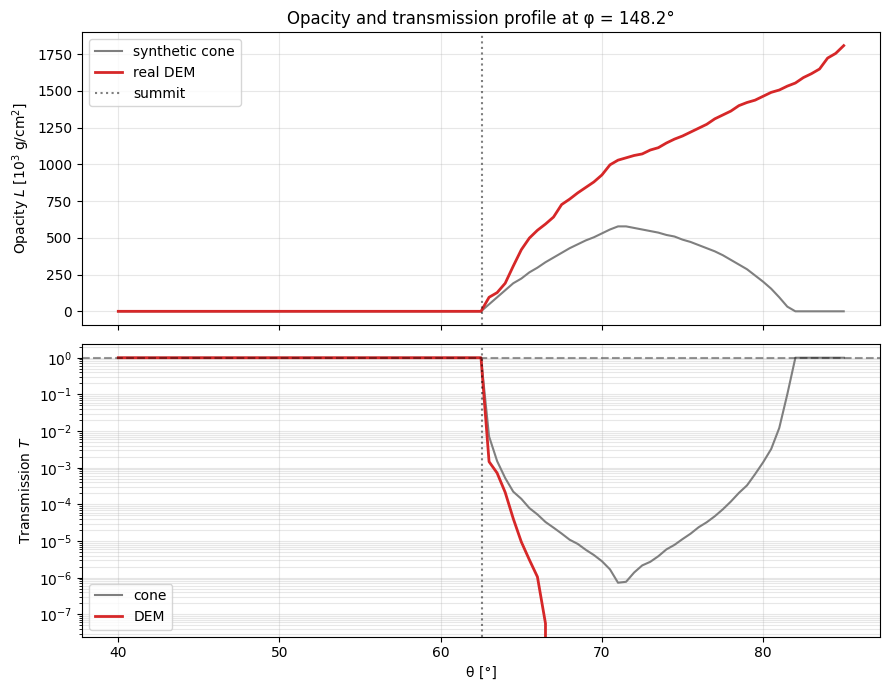

In [10]:
j_phi = int(np.argmin(np.abs(phi_deg - phi_summit_deg)))

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

axes[0].plot(theta_deg, L_cone[:, j_phi]/1000, color='tab:gray', lw=1.5, label='synthetic cone')
axes[0].plot(theta_deg, L_dem[:, j_phi]/1000,  color='tab:red',  lw=2, label='real DEM')
axes[0].set_ylabel('Opacity $L$ [10$^3$ g/cm$^2$]')
axes[0].set_title(f'Opacity and transmission profile at φ = {phi_deg[j_phi]:.1f}°')
axes[0].axvline(theta_summit_deg, color='black', ls=':', alpha=0.5, label='summit')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(theta_deg, T_cone[:, j_phi], color='tab:gray', lw=1.5, label='cone')
axes[1].plot(theta_deg, T_dem[:, j_phi],  color='tab:red',  lw=2, label='DEM')
axes[1].set_yscale('log')
axes[1].set_xlabel('θ [°]')
axes[1].set_ylabel('Transmission $T$')
axes[1].axhline(1.0, color='black', ls='--', alpha=0.4)
axes[1].axvline(theta_summit_deg, color='black', ls=':', alpha=0.5)
axes[1].legend(); axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
fig.savefig(PAPER_FIGS / f'fig_perfil_phi180{VOL_SUFFIX}.png', bbox_inches='tight', dpi=300)
plt.show()

---

## Lectura del muograma DEM

- El muograma DEM tiene **bordes irregulares** que el cono no podía capturar — esas son las pendientes reales del Fuego.
- El **perfil 1D** muestra que el flanco real no es lineal en (θ, opacidad) como el cono — tiene rupturas de pendiente que reflejan terrazas, cráteres anteriores, depósitos piroclásticos recientes.

## El plot del residuo — y por qué es el plot central

### Qué calcula

Una resta píxel a píxel: para cada dirección $(\theta, \varphi)$ del cielo,

$$\Delta L(\theta, \varphi) \;=\; L_{\text{DEM}}(\theta, \varphi) \;-\; L_{\text{cono}}(\theta, \varphi)$$

Las dos $L$ son la **opacidad** (g/cm²) que un rayo en esa dirección recoge atravesando el modelo:

- $L_{\text{cono}}$ — suponiendo que Fuego es un cono perfecto.
- $L_{\text{DEM}}$ — suponiendo el terreno real del Copernicus DEM.

**Ambos modelos usan la MISMA densidad.** Lo único que cambia entre ellos es la **forma geométrica** del cuerpo. Así que cada píxel del residuo está midiendo *cuánto se equivoca el cono en geometría* respecto al terreno real.

### Cómo leer los colores

| Color | Signo | Interpretación física |
|---|---|---|
| **Rojo** | $\Delta L > 0$ | El terreno real tiene **más roca** en esa dirección que el cono predice. Causas: terreno fuera del cono (suelo a los lados, flanco de Acatenango), o la base real del Fuego se extiende debajo del nivel donde corté el cono. |
| **Blanco** | $\Delta L \approx 0$ | El cono acertó. Mayormente: direcciones donde no hay roca en ninguno de los dos modelos. |
| **Azul** | $\Delta L < 0$ | El cono predice **más roca** que la que hay realmente. Causas: el cono es simétrico y "llena" volumen donde el Fuego real tiene barrancos, erosiones o asimetrías que retiran masa. |

### Tres patrones característicos en este residuo

1. **Rojo dominante a θ grande (cerca del horizonte)**. El cono está cortado en z = 2,500 m — por debajo de eso no existe para el modelo. Pero el terreno SÍ existe. Los rayos casi-horizontales tropiezan con kilómetros de terreno que el cono no representa. *Esto no es señal interesante; es un artefacto de cómo definí el cono.*

2. **Anillo rojo/azul en el borde de la sombra**. Donde el flanco real está más adentro que el cono → azul (cono sobreestima). Donde está más afuera → rojo. Es la firma de que los flancos reales no son rectos: tienen pendientes variables. *Esta sí es la asimetría topográfica de Fuego.*

3. **Una franja roja al norte (φ ≈ 130–150°)**. Es Acatenango asomándose al campo de visión. El cono ignoró completamente esa montaña vecina; el DEM no.

### Por qué este plot es la herramienta central de la tesis

En muografía real medís muones con un detector y los comparás con un modelo. El modelo combina **geometría conocida** (el DEM) + **una hipótesis de densidad** (típicamente uniforme). Si la hipótesis fuera cierta:

$$N_{\text{medido}}(\theta, \varphi) \;\approx\; N_{\text{modelo}}(\theta, \varphi)$$

y el residuo debería ser cero dentro del ruido estadístico.

Si el residuo **NO** es cero, sólo hay dos explicaciones posibles:

1. Te equivocaste en la geometría (DEM mal, posición del detector mal, etc.). Esto se descarta validando el DEM contra mediciones GPS o LiDAR.
2. **La densidad no es uniforme.** Donde hay $\Delta N > 0$ (más muones de lo esperado) → la roca es menos densa de lo asumido → posible cavidad / cámara magmática hueca / pumita. Donde hay $\Delta N < 0$ → roca más densa → posible intrusión / domo solidificado / núcleo cristalino.

**Eso es exactamente lo que está buscando un muograma.** No la imagen directa, sino la **diferencia entre lo medido y lo predicho por la geometría**.

En este notebook hicimos el ejercicio "seco": comparamos dos modelos de geometría con la misma densidad. La técnica de mirar residuos es la misma; sólo cambian los operandos. Cuando tengamos un detector real (o un MC realista), el residuo va a contar la **estructura interna** del Fuego, que es el resultado científico final de la tesis.

## Pendientes

1. **Variación de densidad**: ahora la densidad es 2.65 g/cm³ uniforme. Sustituir por un modelo de densidades por capa (lava reciente vs. material piroclástico vs. núcleo intrusivo).
2. **Comparar con MC**: en vez de Reyna analítico, usar el flujo del binario CORSIKA bin por bin angular. Cuantificar el sesgo respecto a Reyna.
3. **Optimización de posición del detector**: mover (det_x, det_y) en un grid alrededor del volcán y elegir la posición que maximiza la "información" del muograma (varianza de T en los pixeles del volcán).
4. **ML**: el surrogate model (Opción A del plan) podría aprender $T(\theta, \varphi; \text{detector})$ directamente de muchos DEMs, ahorrando ray tracing en cada iteración del optimizador del paso 3.

## 7. Comparación con MC: ¿qué tanto sesga Reyna?

Hasta acá la transmisión usó la parametrización analítica de Reyna 2006 (`transmission_map`).
Como contraste, podemos calcular la misma transmisión usando el flujo **empírico** de
muones extraído de una simulación CORSIKA — bin por bin angular. La diferencia
$T_{MC} - T_{Reyna}$ aísla el sesgo sistemático introducido por la aproximación analítica.

Para esto cargamos una corrida MC del volcán objetivo (se elige automáticamente la de
mayor NSHOW de las disponibles en `sim/runs.csv`). El cómputo MC tarda ~1 s.

In [11]:
from analysis.muograma import mc_transmission_map
from analysis.corsika import CorsikaRun

# Auto-pick the highest-stat run for this TARGET_VOLCAN
_runs = pd.read_csv(REPO_ROOT / 'sim' / 'runs.csv')
_vol_runs = _runs[(_runs['volcan'] == TARGET_VOLCAN) & (_runs['status'] == 'ok')]
if _vol_runs.empty:
    raise RuntimeError(
        f'No hay corridas ok para {TARGET_VOLCAN} en sim/runs.csv. '
        f'Corré `make batch-start` con un plan que incluya {TARGET_VOLCAN}.'
    )
RUNNR_MC = int(_vol_runs.loc[_vol_runs['nshow'].idxmax(), 'runnr'])
print(f'Usando RUNNR={RUNNR_MC} (volcan={TARGET_VOLCAN}, NSHOW={int(_vol_runs.loc[_vol_runs["nshow"].idxmax(), "nshow"]):,})')

mc_run = CorsikaRun(REPO_ROOT / 'sim' / 'output', run_number=RUNNR_MC)
muons = mc_run.particles.muons()
print(f'Muones cargados: {len(muons):,}')

# Compute T_mc using the same opacity grid as T_dem
T_mc = mc_transmission_map(L_dem, theta_rad, muons, theta_bin_width_deg=5.0, min_per_bin=50)
n_valid = np.isfinite(T_mc).sum()
print(f'Pixeles con MC válido: {n_valid:,} / {T_mc.size:,} ({n_valid/T_mc.size:.1%})')

Usando RUNNR=13 (volcan=fuego, NSHOW=150,000)


/home/jarjarbinks/muon-tomography/.venv/lib/python3.13/site-packages/corsikaio/subblocks/run_header.py:84: UserWarning: Version unknown, using run header definition dtype of version 7.x
  warnings.warn("Version unknown, using run header definition dtype of version 7.x")
/home/jarjarbinks/muon-tomography/.venv/lib/python3.13/site-packages/corsikaio/subblocks/event_header.py:144: UserWarning: Version unknown, using event header dtype definition of version 7.7XXX
  warnings.warn("Version unknown, using event header dtype definition of version 7.7XXX")
/home/jarjarbinks/muon-tomography/.venv/lib/python3.13/site-packages/corsikaio/subblocks/event_end.py:46: UserWarning: Version unknown, using default event end definition dtype of version 7.x
  warnings.warn("Version unknown, using default event end definition dtype of version 7.x")


Muones cargados: 43,988
Pixeles con MC válido: 19,280 / 21,931 (87.9%)


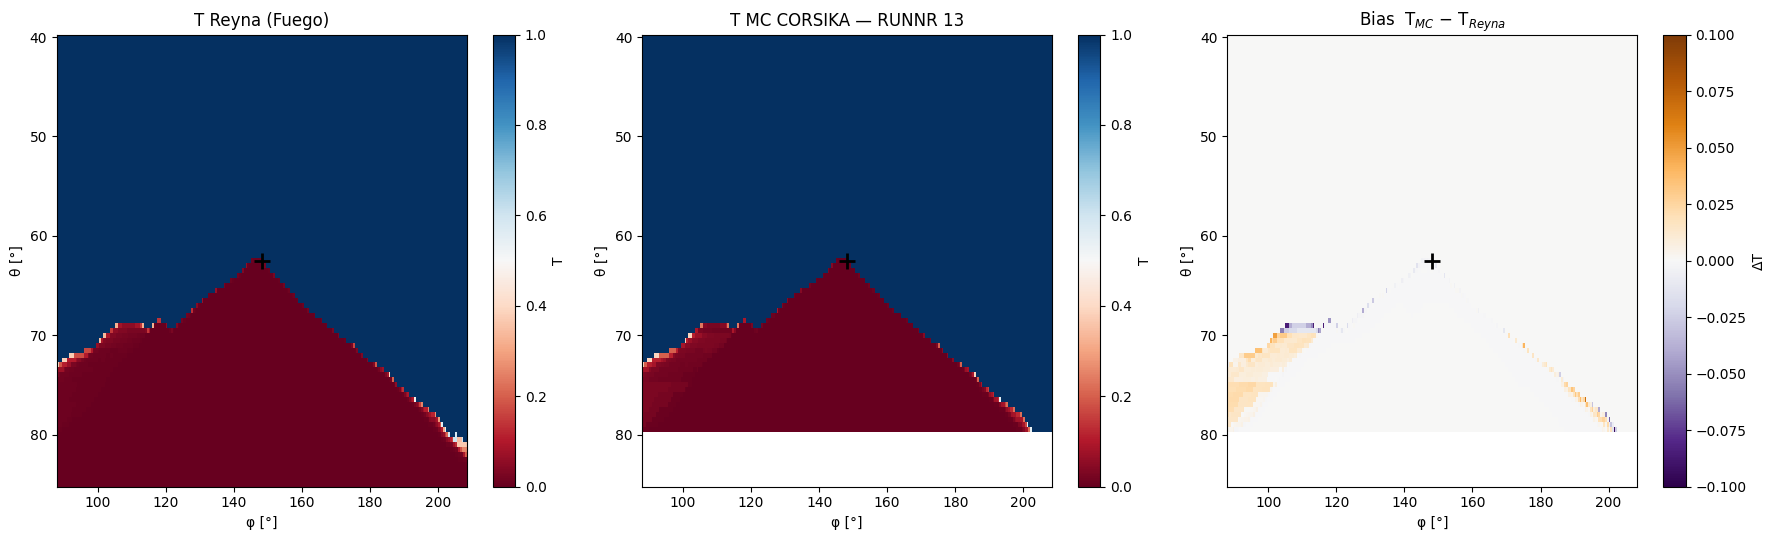

Bias en píxeles con roca (n=4,697):
  media : +0.0011
  std   : 0.0069
  max|· |: 0.0927
Bias global (n=19,280):
  media : +0.0003
  std   : 0.0034


In [12]:
# Side-by-side plot: T_reyna, T_mc, bias = T_mc - T_reyna
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

T_bias = T_mc - T_dem

for ax, mat, title, cmap, vmin, vmax in [
    (axes[0], T_dem,  f'T Reyna ({TARGET_VOLCAN.title()})',            'RdBu', 0, 1),
    (axes[1], T_mc,   f'T MC CORSIKA — RUNNR {RUNNR_MC}',              'RdBu', 0, 1),
    (axes[2], T_bias, f'Bias  T$_{{MC}}$ − T$_{{Reyna}}$',             'PuOr_r', -0.1, 0.1),
]:
    im = ax.pcolormesh(PHI, THETA, mat, cmap=cmap, shading='auto', vmin=vmin, vmax=vmax)
    ax.scatter(phi_summit_deg, theta_summit_deg, marker='+', s=140, color='black', lw=2)
    ax.set_xlabel('φ [°]'); ax.set_ylabel('θ [°]')
    ax.invert_yaxis()
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label=('T' if 'Bias' not in title else 'ΔT'))

plt.tight_layout()
fig.savefig(PAPER_FIGS / f'fig_mc_vs_reyna{VOL_SUFFIX}.png',
            bbox_inches='tight', dpi=300)
plt.show()

# Stats over volcano pixels (where the cone has rock — proxy for relevant region)
in_volcan = (L_dem > 0) & np.isfinite(T_bias)
if in_volcan.any():
    bias_vol = T_bias[in_volcan]
    print(f'Bias en píxeles con roca (n={in_volcan.sum():,}):')
    print(f'  media : {bias_vol.mean():+.4f}')
    print(f'  std   : {bias_vol.std():.4f}')
    print(f'  max|· |: {np.abs(bias_vol).max():.4f}')
print(f'Bias global (n={np.isfinite(T_bias).sum():,}):')
print(f'  media : {T_bias[np.isfinite(T_bias)].mean():+.4f}')
print(f'  std   : {T_bias[np.isfinite(T_bias)].std():.4f}')

**Cómo leer el bias:**

- **Cercano a cero en todas partes** → Reyna es buena aproximación; la elección de parametrización analítica no afecta resultados a primer orden.
- **Positivo sistemático en píxeles con roca** → Reyna subestima la transmisión (sobrestima la sombra). Implica que el flujo real de muones a altas energías es mayor del que predice Reyna.
- **Negativo sistemático** → al revés.
- **Variación estructural en (θ, φ)** → la dependencia angular de Reyna difiere de CORSIKA, podría reflejar diferencias del modelo hadrónico (DPMJET vs el que parametrizó Reyna).

El bias se va a publicar como **incertidumbre sistemática** en el paper (Section Discussion).

---

## 8. Vista 2D del setup — detector apuntando al cráter

Plan view (vista desde arriba) del DEM con el detector marcado, el cráter, y la línea
de vista entre ambos con su ángulo azimutal. Útil para entender la geometría sin
abrir el muograma.

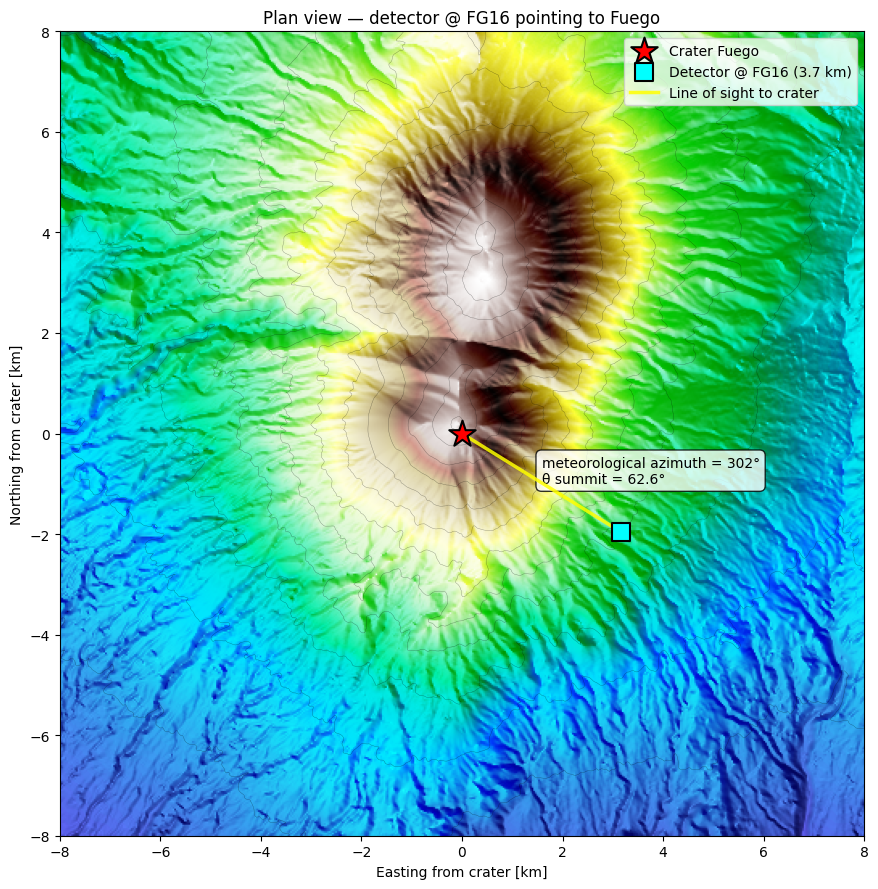

In [13]:
# Larger window than the muograma cells: extent_m=8000 lets us show the
# detector position even when it's at the edge of the ±5 km window.
plan_extent_m = max(8000, int(np.hypot(det_x, det_y) * 1.3))
xs2 = np.linspace(-plan_extent_m, plan_extent_m, 500)
ys2 = np.linspace(-plan_extent_m, plan_extent_m, 500)
X2, Y2 = np.meshgrid(xs2, ys2)
Z2 = terrain.elevation_at(X2, Y2)

ls2 = LightSource(azdeg=315, altdeg=45)
rgb2 = ls2.shade(Z2, cmap=plt.cm.terrain, vert_exag=2.0, blend_mode='overlay')

fig, ax = plt.subplots(figsize=(10, 9))
ax.imshow(rgb2, extent=[-plan_extent_m/1000, plan_extent_m/1000]*2, origin='lower')
ax.contour(X2/1000, Y2/1000, Z2, levels=np.arange(1000, 4500, 250),
           colors='k', linewidths=0.3, alpha=0.4)

# Crater
ax.scatter(0, 0, marker='*', s=400, color='red', edgecolor='black', lw=1.5, zorder=10,
           label=f'Crater {TARGET_VOLCAN.title()}')
# Detector
ax.scatter(det_x/1000, det_y/1000, marker='s', s=160, color='cyan',
           edgecolor='black', lw=1.5, zorder=10,
           label=f"Detector @ {_site['name']} ({_site['dist_km']:.1f} km)")
# Line of sight
ax.plot([det_x/1000, 0], [det_y/1000, 0], color='yellow', lw=2.5, alpha=0.85,
        linestyle='-', zorder=8, label='Line of sight to crater')

# Annotate azimuth (meteorological: 0=N, clockwise)
az_meteo = (90.0 - phi_summit_deg) % 360.0
ax.annotate(
    f"meteorological azimuth = {az_meteo:.0f}°\n"
    f"θ summit = {theta_summit_deg:.1f}°",
    xy=(det_x/2000, det_y/2000), fontsize=10, color='black',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8),
)

ax.set_xlabel('Easting from crater [km]')
ax.set_ylabel('Northing from crater [km]')
ax.set_title(f'Plan view — detector @ {_site["name"]} pointing to {TARGET_VOLCAN.title()}')
ax.set_aspect('equal')
ax.legend(loc='upper right')
plt.tight_layout()
fig.savefig(PAPER_FIGS / f'fig_planview{VOL_SUFFIX}.png',
            bbox_inches='tight', dpi=300)
plt.show()

### Perfil de elevación a lo largo de la línea de vista

Cortando verticalmente el terreno desde el detector hasta el cráter (y un poco más allá), se ve
*cuánta roca hay literalmente en el camino*. La línea recta en este plot es la trayectoria
del muón si entrara horizontal a la cima; el área entre la trayectoria y el terreno es el
volumen atravesado.

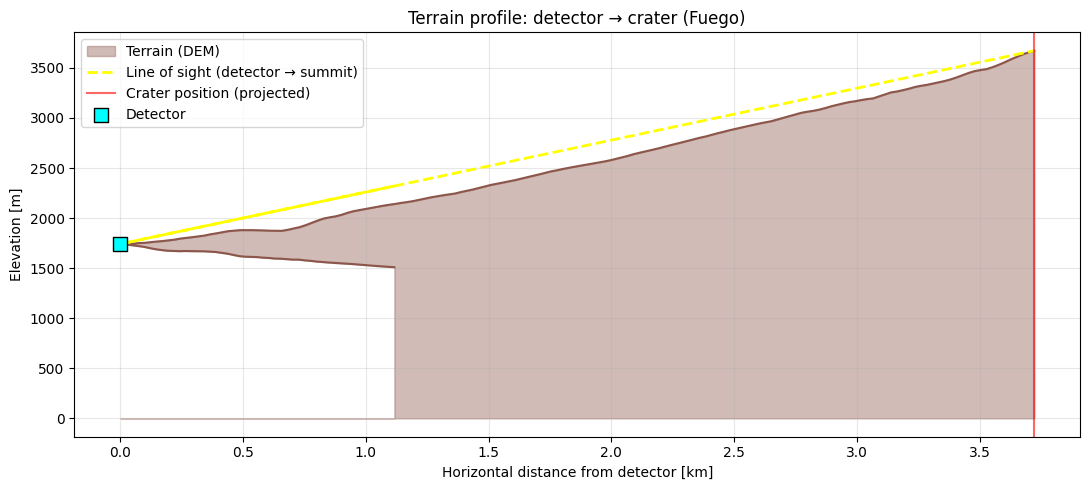

In [14]:
# Sample DEM elevation along the line from detector to a bit beyond the crater
n_samples = 200
overshoot = 0.3  # extend 30% past the crater on the far side
t = np.linspace(-overshoot, 1.0, n_samples)  # t=0 at detector, t=1 at crater
xs_los = det_x * (1 - t)
ys_los = det_y * (1 - t)
zs_terrain = terrain.elevation_at(xs_los, ys_los)
distance_along = np.sqrt((det_x - xs_los)**2 + (det_y - ys_los)**2)

# Direct path from detector to summit
zs_lineofsight = det_z + (summit_z - det_z) * (distance_along / np.hypot(det_x, det_y))

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(distance_along/1000, zs_terrain, color='tab:brown', alpha=0.4,
                label='Terrain (DEM)')
ax.plot(distance_along/1000, zs_terrain, color='tab:brown', lw=1.5)
ax.plot(distance_along/1000, zs_lineofsight, color='yellow', lw=2, linestyle='--',
        label='Line of sight (detector → summit)')
ax.axvline(np.hypot(det_x, det_y)/1000, color='red', lw=1.5, alpha=0.6,
           label='Crater position (projected)')
ax.scatter([0], [det_z], marker='s', s=100, color='cyan', edgecolor='black', zorder=10,
           label='Detector')

ax.set_xlabel('Horizontal distance from detector [km]')
ax.set_ylabel('Elevation [m]')
ax.set_title(f'Terrain profile: detector → crater ({TARGET_VOLCAN.title()})')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(PAPER_FIGS / f'fig_los_profile{VOL_SUFFIX}.png',
            bbox_inches='tight', dpi=300)
plt.show()

## 9. Vista 3D del DEM con detector + línea de vista

Superficie 3D del DEM ±5 km alrededor del cráter, con el detector marcado y la línea recta
detector → cima. Útil para presentaciones / charlas o como figura de apertura de Section 3
del paper. Notebook estático; para una vista interactiva, usar `%matplotlib widget` o exportar
a plotly más adelante.

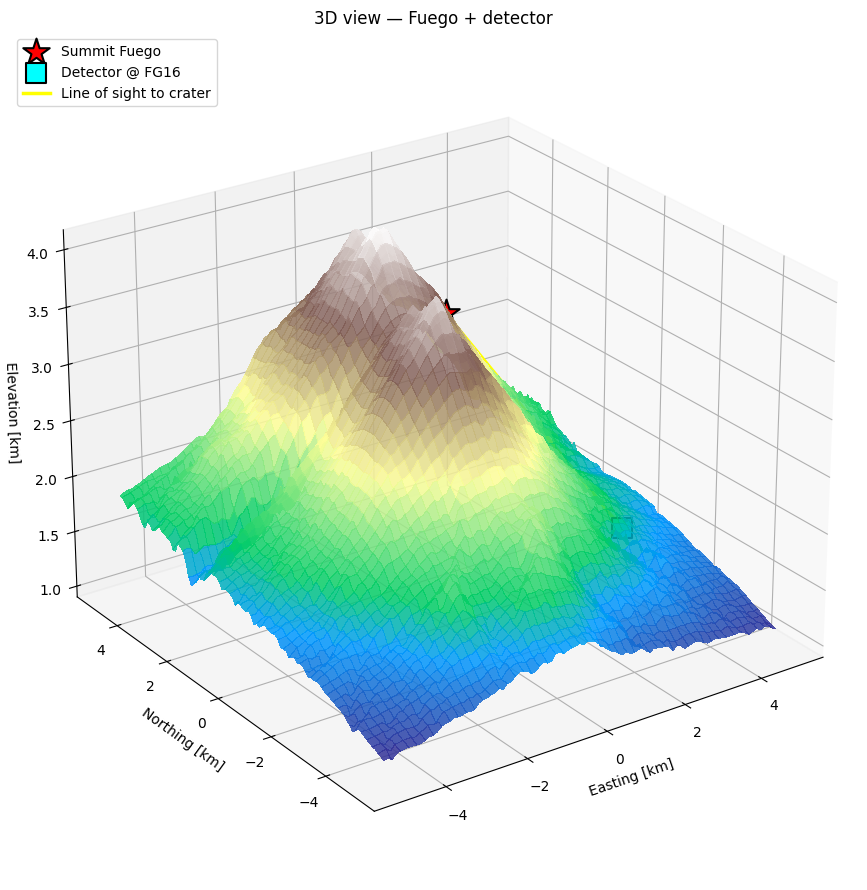

In [15]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers 3d projection)

# Reuse the X, Y, Z computed at the top of the notebook (±5 km window)
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Subsample to keep render fast
stride = 4
ax.plot_surface(X[::stride, ::stride]/1000,
                Y[::stride, ::stride]/1000,
                Z[::stride, ::stride]/1000,
                cmap='terrain', alpha=0.85, linewidth=0, antialiased=False)

# Crater (star at summit elevation)
ax.scatter([0], [0], [summit_z/1000], marker='*', s=400, color='red',
           edgecolor='black', linewidth=1.5, label=f'Summit {TARGET_VOLCAN.title()}')

# Detector (cube at its position)
ax.scatter([det_x/1000], [det_y/1000], [det_z/1000], marker='s', s=200, color='cyan',
           edgecolor='black', linewidth=1.5, label=f"Detector @ {_site['name']}")

# Line of sight
ax.plot([det_x/1000, 0], [det_y/1000, 0], [det_z/1000, summit_z/1000],
        color='yellow', lw=2.5, label='Line of sight to crater')

# View angle: looking from above + side
ax.view_init(elev=25, azim=235)

ax.set_xlabel('Easting [km]')
ax.set_ylabel('Northing [km]')
ax.set_zlabel('Elevation [km]')
ax.set_title(f'3D view — {TARGET_VOLCAN.title()} + detector')
ax.legend(loc='upper left')
plt.tight_layout()
fig.savefig(PAPER_FIGS / f'fig_3d_setup{VOL_SUFFIX}.png',
            bbox_inches='tight', dpi=300)
plt.show()